# check spurious transcripts

In [1]:
# %% Libraries

import os
import scanpy as sc
import numpy as np
from pathlib import Path
import rapids_singlecell as rsc
import pandas as pd
from scipy.sparse import issparse

# %% Setting Paths
MAIN_DIR_NAME = "proseg_data"
MAIN_DIR = next(p for p in Path.cwd().parents if (p / MAIN_DIR_NAME).exists()) / MAIN_DIR_NAME
os.chdir(MAIN_DIR)

# %% Setting Seed
SEED_VALUE = 42
# set NumPy RNG for consistency
np.random.seed(SEED_VALUE)

# %% object versions
COMB_V= 'counts-corrected'
COMB_PATH = MAIN_DIR / 'data' / 'comb' / 'h5ad' / f'comb-{COMB_V}.h5ad'


/mnt/data/project0062/.conda/envs/rsc_25.12/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# %% Load the object
comb = sc.read_h5ad(COMB_PATH)

In [3]:
import numpy as np
from scipy import sparse

counts = comb.layers["counts"]
corrected = comb.layers["generated_expression"]

assert counts.shape == corrected.shape

# store as float32 to reduce RAM
spurious = np.empty(
    corrected.shape,
    dtype=np.float32,
)

chunk_size = 10_000

for start in range(0, comb.n_obs, chunk_size):

    end = min(start + chunk_size, comb.n_obs)

    # observed counts
    if sparse.issparse(counts):
        obs_chunk = counts[start:end].toarray().astype(np.float32)
    else:
        obs_chunk = np.asarray(
            counts[start:end],
            dtype=np.float32,
        )

    # ResolVI corrected counts
    corr_chunk = np.asarray(
        corrected[start:end],
        dtype=np.float32,
    )

    # estimated spurious counts
    spurious[start:end] = np.maximum(
        obs_chunk - corr_chunk,
        0,
    )

comb.layers["spurious_expression"] = spurious

In [4]:
comb.layers["counts"]
# observed counts

comb.layers["generated_expression"]
# ResolVI corrected / inferred true expression

comb.layers["spurious_expression"]
# estimated removed/spurious expression

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]],
      shape=(1187341, 2000), dtype=float32)

In [5]:
import numpy as np
import pandas as pd
from scipy import sparse

cell_type = "Gob"

idx = (
    comb.obs["ann_lvl_3_refined"] == cell_type
).values

# observed counts
obs = comb.layers["counts"][idx]

if sparse.issparse(obs):
    observed_counts = np.asarray(obs.sum(axis=0)).ravel()
    detected_cells = np.asarray((obs > 0).sum(axis=0)).ravel()
else:
    observed_counts = np.asarray(obs.sum(axis=0)).ravel()
    detected_cells = np.asarray((obs > 0).sum(axis=0)).ravel()

# ResolVI corrected expression
corr = comb.layers["generated_expression"][idx]

corrected_counts = np.asarray(
    corr.sum(axis=0)
).ravel()

spurious_df = pd.DataFrame({
    "gene": comb.var_names,
    "observed_counts": observed_counts,
    "corrected_counts": corrected_counts,
    "detected_cells": detected_cells,
})

# group-level amount reduced by ResolVI
spurious_df["removed_fraction"] = np.clip(
    1 - (
        spurious_df["corrected_counts"]
        / spurious_df["observed_counts"]
    ),
    0,
    1,
)

spurious_df = spurious_df.replace(
    [np.inf, -np.inf],
    np.nan,
)

In [6]:
eligible = (
    (spurious_df["observed_counts"] >= 50) &
    (spurious_df["detected_cells"] >= 10)
)

In [7]:
cutoff = spurious_df.loc[
    eligible,
    "removed_fraction"
].quantile(0.90)

spurious_df["candidate_spurious"] = (
    eligible &
    (spurious_df["removed_fraction"] >= cutoff)
)

spurious_df.sort_values(
    ["candidate_spurious", "removed_fraction", "observed_counts"],
    ascending=[False, False, False],
).head(50)

,gene,observed_counts,corrected_counts,detected_cells,removed_fraction,candidate_spurious
412,COMP,1096,0.333840,1008,0.999695,True
929,IGLV4-69,705,0.430740,645,0.999389,True
1905,TRDC,639,0.489544,593,0.999234,True
917,IGHD,482,0.445231,453,0.999076,True
1194,MLLT11,2494,2.351541,2173,0.999057,True
1369,P2RX7,1131,1.152573,1030,0.998981,True
1481,POMC,1822,1.894022,1564,0.998960,True
1209,MOG,2680,2.802493,2168,0.998954,True
730,GALR3,974,1.159423,899,0.998810,True
1055,LAG3,1560,1.915808,1398,0.998772,True


In [8]:
spurious_df[spurious_df["gene"] == "IGKC"]

,gene,observed_counts,corrected_counts,detected_cells,removed_fraction,candidate_spurious
922,IGKC,19987,21479.054688,9414,0.0,False


In [9]:
spurious_df[spurious_df["gene"] == "IGLC1/2"]

,gene,observed_counts,corrected_counts,detected_cells,removed_fraction,candidate_spurious
924,IGLC1/2,4679,3619.120117,3529,0.226518,False


In [10]:
spurious_df[spurious_df["gene"] == "IGHG1/2"]

,gene,observed_counts,corrected_counts,detected_cells,removed_fraction,candidate_spurious
918,IGHG1/2,10760,1773.7229,6537,0.835156,False


In [11]:
spurious_df[spurious_df["gene"] == "IGHA1"]

,gene,observed_counts,corrected_counts,detected_cells,removed_fraction,candidate_spurious
916,IGHA1,11062,13283.839844,6441,0.0,False


In [12]:
spurious_df[spurious_df["gene"] == "IGHM"]

,gene,observed_counts,corrected_counts,detected_cells,removed_fraction,candidate_spurious
919,IGHM,1410,62.810299,1193,0.955454,False


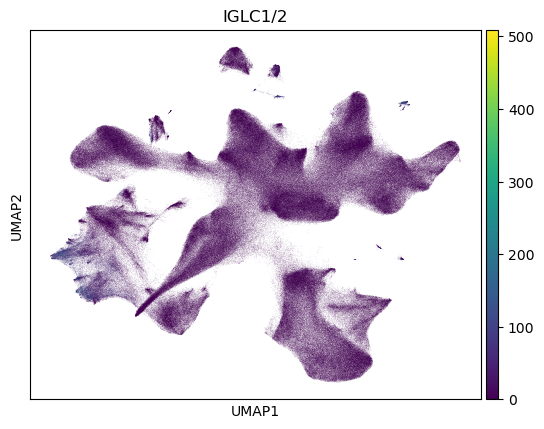

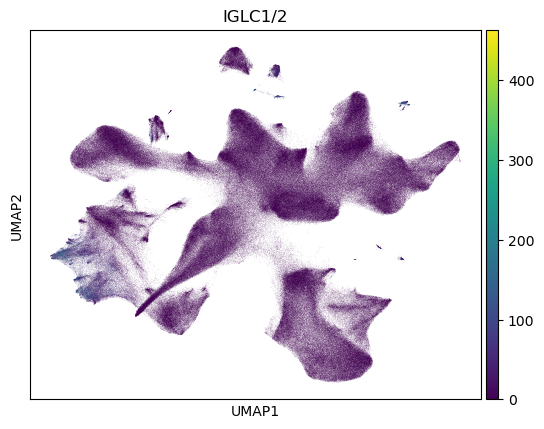

In [13]:
sc.pl.umap(
    comb, 
    color=["IGLC1/2"],
    #groups=[''],
    layer = 'counts',
    legend_loc="on data"
)
sc.pl.umap(
    comb, 
    color=["IGLC1/2"],
    #groups=[''],
    layer = 'generated_expression',
    legend_loc="on data"
)

# Check IGKC contamination

In [20]:
import numpy as np
import pandas as pd
from scipy import sparse

counts = comb.layers["counts"]

def get_gene_counts(adata, gene):
    idx = adata.var_names.get_loc(gene)
    x = adata.layers["counts"][:, idx]

    if sparse.issparse(x):
        return np.asarray(x.toarray()).ravel()

    return np.asarray(x).ravel()


# get ig genes in comb.vars
# Get immunoglobulin genes in comb.var_names
ig_genes = comb.var_names[
    comb.var_names.str.startswith(("IGH", "IGK", "IGL"))
].tolist()

ig_genes

idx = [comb.var_names.get_loc(g) for g in ig_genes]

ig_counts = comb.layers["counts"][:, idx].sum(axis=1)

comb.obs["IG_counts"] = np.asarray(ig_counts).ravel()

comb.obs["IG_fraction"] = (
    comb.obs["IG_counts"] /
    comb.obs["total_counts_raw"]
)

In [25]:
ig_sources = [
    "B",
    "PC_K_IgAG",
    "PC_K_IgM",
    "PC_K_IgG",
    "PC_K_IgA",
    "PC_L_IgA",
    "PC_L_IgG",
]

comb.obs["canonical_IG_cell"] = (
    comb.obs["ann_lvl_3_refined"]
    .isin(ig_sources)
)

In [27]:
non_ig = comb.obs.loc[
    ~comb.obs["canonical_IG_cell"]
].copy()

non_ig.groupby("ann_lvl_3_refined").agg(
    n_cells=("IG_counts", "size"),
    cells_with_IGKC=("IG_counts", lambda x: (x > 0).sum()),
    pct_with_IG=("IG_counts", lambda x: (x > 0).mean() * 100),
    mean_IG=("IG_counts", "mean"),
    median_IG=("IG_counts", "median"),
    mean_IG_fraction=("IG_fraction", "mean"),
)

/tmp/ipykernel_341127/1825378605.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  non_ig.groupby("ann_lvl_3_refined").agg(


,n_cells,cells_with_IGKC,pct_with_IG,mean_IG,median_IG,mean_IG_fraction
ann_lvl_3_refined,,,,,,
AT1,22890,7229,31.581477,0.733159,0.0,0.006207
AT2,89789,43076,47.974696,1.699150,0.0,0.009728
AlvMac,18292,9219,50.399082,1.948502,1.0,0.006037
Amb,78828,37047,46.997260,1.539110,0.0,0.008796
B,0,0,NaN,NaN,NaN,NaN
BC,62840,27051,43.047422,1.072454,0.0,0.010629
CD4_T,13817,6451,46.688862,1.617355,0.0,0.020448
CD8_T,16786,6761,40.277612,0.973609,0.0,0.013276
Club,36891,18318,49.654387,1.349896,0.0,0.007325


In [28]:
qc = comb.obs[
    ["sample_name", "condition", "ann_lvl_3_refined"]
].copy()

qc["IG_counts"] = comb.obs["IG_counts"].values
qc["IG_fraction"] = comb.obs["IG_fraction"].values
qc["IG_positive"] = qc["IG_counts"] > 0

ig_sample = (
    qc
    .groupby(
        ["sample_name", "condition", "ann_lvl_3_refined"],
        observed=True
    )
    .agg(
        n_cells=("IG_counts", "size"),
        cells_with_IG=("IG_positive", "sum"),
        pct_with_IG=("IG_positive", "mean"),
        mean_IG=("IG_counts", "mean"),
        median_IG=("IG_counts", "median"),
        mean_IG_fraction=("IG_fraction", "mean"),
        total_IG=("IG_counts", "sum"),
    )
    .reset_index()
)

ig_sample["pct_with_IG"] *= 100

In [34]:
ig_sample[
    ig_sample["ann_lvl_3_refined"] == "actFib"
].sort_values("condition")

,sample_name,condition,ann_lvl_3_refined,n_cells,cells_with_IG,pct_with_IG,mean_IG,median_IG,mean_IG_fraction,total_IG
168,PWCF01_1,CF,actFib,3972,2315,58.282981,2.693857,1.0,0.013497,10700
197,PWCF01_2,CF,actFib,6147,4303,70.001627,4.900277,2.0,0.020516,30122
226,PWCF02,CF,actFib,8714,2426,27.840257,0.534427,0.0,0.011121,4657
255,PWCF03,CF,actFib,4537,1480,32.620674,0.622438,0.0,0.012513,2824
313,PWCF05,CF,actFib,4465,1413,31.646137,0.964166,0.0,0.014369,4305
284,PWCF04,CF_ETI,actFib,1234,388,31.442464,0.581848,0.0,0.018406,718
342,PWCF06,CF_ETI,actFib,3254,1395,42.870313,1.450215,0.0,0.014541,4719
25,CTRL01,CTRL,actFib,1149,229,19.930374,0.369017,0.0,0.006085,424
54,CTRL02,CTRL,actFib,815,208,25.521472,0.468712,0.0,0.006434,382
83,CTRL03,CTRL,actFib,408,43,10.539216,0.164216,0.0,0.003370,67
